# States I: band structure (momentum space)
Diagonalizing the Bloch Hamiltonian $H(\mathbf k)$ gives the eigenstates $|\Psi_k\rangle$ ("states" in momentum space) and their energies $\epsilon_k$:
$$ H(\mathbf k)\,|\Psi_k\rangle = \epsilon_k\,|\Psi_k\rangle $$
Plotting $\epsilon_k$ along a path in the Brillouin zone is the band structure. We compare two lattices with very different low-energy physics: the honeycomb lattice (linear, Dirac-cone bands) and the kagome lattice (a dispersionless, flat band from destructive interference).
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### Honeycomb lattice: Dirac cones
$$ H = \sum_{\langle ij \rangle} c^\dagger_i c_j $$

In [2]:
g_honey = geometry.honeycomb_lattice()
h_honey = g_honey.get_hamiltonian()
(k_honey,e_honey) = h_honey.get_bands()

### Kagome lattice: a flat band
Same first-neighbor hopping, but the kagome geometry makes one of the three bands completely flat (energy independent of $\mathbf k$), a hallmark of geometric frustration/interference.

In [3]:
g_kagome = geometry.kagome_lattice()
h_kagome = g_kagome.get_hamiltonian()
(k_kagome,e_kagome) = h_kagome.get_bands()

### Plot both band structures

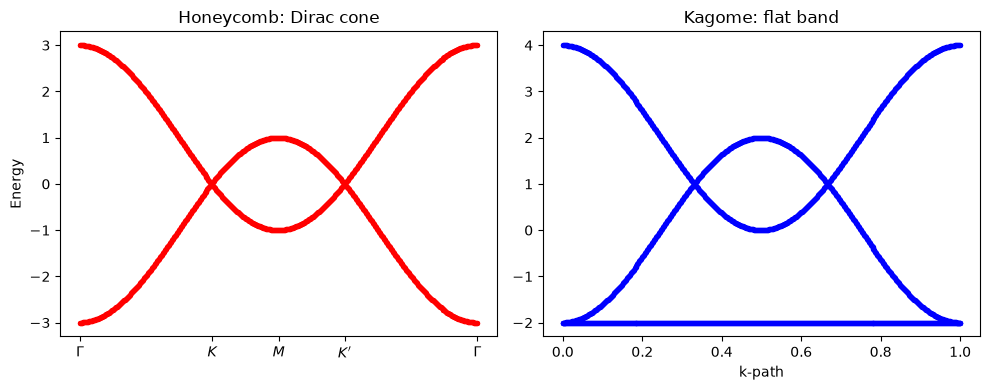

In [4]:
fig, axes = plt.subplots(1,2,figsize=(10,4))

axes[0].scatter(k_honey/max(k_honey), e_honey, c="red", s=8)
axes[0].set_title("Honeycomb: Dirac cone")
axes[0].set_xticks([0.,1/3.,0.5,2./3.,1.])
axes[0].set_xticklabels(["$\Gamma$","$K$","$M$","$K'$","$\Gamma$"])
axes[0].set_ylabel("Energy")

axes[1].scatter(k_kagome/max(k_kagome), e_kagome, c="blue", s=8)
axes[1].set_title("Kagome: flat band")
axes[1].set_xlabel("k-path")

plt.tight_layout()
plt.show()

### Opening a gap: sublattice imbalance (Semenoff mass)
Adding an energy offset $M$ with opposite sign on the two honeycomb sublattices,
$$ H_M = M\sum_i \xi_i\, c^\dagger_i c_i,\qquad \xi_i = \pm 1 \text{ on sublattice A/B} $$
breaks inversion symmetry and gaps out the Dirac points.

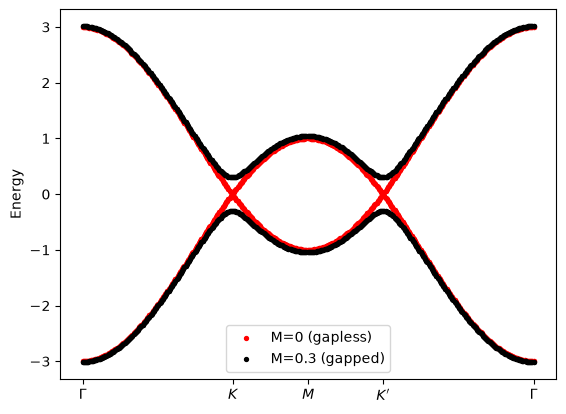

In [5]:
h_gapped = h_honey.copy()
h_gapped.add_sublattice_imbalance(0.3) # mass term M=0.3
(kg,eg) = h_gapped.get_bands()

plt.scatter(k_honey/max(k_honey), e_honey, c="red", s=8, label="M=0 (gapless)")
plt.scatter(kg/max(kg), eg, c="black", s=8, label="M=0.3 (gapped)")
plt.xticks([0.,1/3.,0.5,2./3.,1.],["$\Gamma$","$K$","$M$","$K'$","$\Gamma$"])
plt.ylabel("Energy")
plt.legend()
plt.show()